## 1. Import libraries and load both datasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)

accident = pd.read_csv("accident.csv", low_memory=False)
vehicle = pd.read_csv("vehicle.csv", low_memory=False)

print("Files loaded successfully")
print("Accident shape:", accident.shape)
print("Vehicle shape:", vehicle.shape)

Files loaded successfully
Accident shape: (200352, 23)
Vehicle shape: (365470, 37)


## 2. Inspect the datasets

In [4]:
print("ACCIDENT DATA COLUMNS")
print(accident.columns.tolist())

print("\nVEHICLE DATA COLUMNS")
print(vehicle.columns.tolist())

print("\nACCIDENT SAMPLE")
display(accident.head())

print("\nVEHICLE SAMPLE")
display(vehicle.head())

ACCIDENT DATA COLUMNS
['ACCIDENT_NO', 'ACCIDENT_DATE', 'ACCIDENT_TIME', 'ACCIDENT_TYPE', 'ACCIDENT_TYPE_DESC', 'DAY_OF_WEEK', 'DAY_WEEK_DESC', 'DCA_CODE', 'DCA_DESC', 'LIGHT_CONDITION', 'NODE_ID', 'NO_OF_VEHICLES', 'NO_PERSONS_KILLED', 'NO_PERSONS_INJ_2', 'NO_PERSONS_INJ_3', 'NO_PERSONS_NOT_INJ', 'NO_PERSONS', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'ROAD_GEOMETRY_DESC', 'SEVERITY', 'SPEED_ZONE', 'RMA']

VEHICLE DATA COLUMNS
['ACCIDENT_NO', 'VEHICLE_ID', 'VEHICLE_YEAR_MANUF', 'VEHICLE_DCA_CODE', 'INITIAL_DIRECTION', 'ROAD_SURFACE_TYPE', 'ROAD_SURFACE_TYPE_DESC', 'REG_STATE', 'VEHICLE_BODY_STYLE', 'VEHICLE_MAKE', 'VEHICLE_MODEL', 'VEHICLE_POWER', 'VEHICLE_TYPE', 'VEHICLE_TYPE_DESC', 'VEHICLE_WEIGHT', 'CONSTRUCTION_TYPE', 'FUEL_TYPE', 'NO_OF_WHEELS', 'NO_OF_CYLINDERS', 'SEATING_CAPACITY', 'TARE_WEIGHT', 'TOTAL_NO_OCCUPANTS', 'CARRY_CAPACITY', 'CUBIC_CAPACITY', 'FINAL_DIRECTION', 'DRIVER_INTENT', 'VEHICLE_MOVEMENT', 'TRAILER_TYPE', 'VEHICLE_COLOUR_1', 'VEHICLE_COLOUR_2', 'CAUGHT_FIRE', 'INITIAL

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,ACCIDENT_TYPE_DESC,DAY_OF_WEEK,DAY_WEEK_DESC,DCA_CODE,DCA_DESC,LIGHT_CONDITION,NODE_ID,NO_OF_VEHICLES,NO_PERSONS_KILLED,NO_PERSONS_INJ_2,NO_PERSONS_INJ_3,NO_PERSONS_NOT_INJ,NO_PERSONS,POLICE_ATTEND,ROAD_GEOMETRY,ROAD_GEOMETRY_DESC,SEVERITY,SPEED_ZONE,RMA
0,T20120002354,2012-01-31,10:35:00,1,Collision with vehicle,3,Tuesday,121,RIGHT THROUGH,1,277152,2,0,1,1,1,3,1,1,Cross intersection,2,60,Arterial Highway
1,T20120002508,2012-02-02,07:55:00,1,Collision with vehicle,5,Thursday,121,RIGHT THROUGH,1,40762,2,0,2,1,0,3,1,1,Cross intersection,2,70,Arterial Highway
2,T20120003232,2012-02-10,14:20:00,1,Collision with vehicle,6,Friday,121,RIGHT THROUGH,1,609188,2,0,1,0,2,3,1,5,Not at intersection,2,60,Arterial Other
3,T20120004288,2012-02-17,08:40:00,1,Collision with vehicle,6,Friday,143,ENTERING PARKING,1,249923,2,0,0,1,1,2,2,5,Not at intersection,3,40,Arterial Other
4,T20120004516,2012-02-24,15:30:00,2,Struck Pedestrian,6,Friday,101,PED EMERGES FROM IN FRONT OF PARKED OR STATIONARY VEHICLE,1,249991,1,0,0,1,1,2,1,5,Not at intersection,3,50,Local Road



VEHICLE SAMPLE


,ACCIDENT_NO,VEHICLE_ID,VEHICLE_YEAR_MANUF,VEHICLE_DCA_CODE,INITIAL_DIRECTION,ROAD_SURFACE_TYPE,ROAD_SURFACE_TYPE_DESC,REG_STATE,VEHICLE_BODY_STYLE,VEHICLE_MAKE,VEHICLE_MODEL,VEHICLE_POWER,VEHICLE_TYPE,VEHICLE_TYPE_DESC,VEHICLE_WEIGHT,CONSTRUCTION_TYPE,FUEL_TYPE,NO_OF_WHEELS,NO_OF_CYLINDERS,SEATING_CAPACITY,TARE_WEIGHT,TOTAL_NO_OCCUPANTS,CARRY_CAPACITY,CUBIC_CAPACITY,FINAL_DIRECTION,DRIVER_INTENT,VEHICLE_MOVEMENT,TRAILER_TYPE,VEHICLE_COLOUR_1,VEHICLE_COLOUR_2,CAUGHT_FIRE,INITIAL_IMPACT,LAMPS,LEVEL_OF_DAMAGE,TOWED_AWAY_FLAG,TRAFFIC_CONTROL,TRAFFIC_CONTROL_DESC
0,T20120000009,A,1996.0,1.0,E,1.0,Paved,V,SEDAN,HOLDEN,ACCLAI,NaN,1,Car,NaN,R,P,4.0,6.0,5.0,1350.0,2.0,NaN,NaN,E,1.0,18.0,H,WHI,ZZ,2.0,1,1.0,5,1.0,0.0,No control
1,T20120000043,A,2006.0,2.0,SE,1.0,Paved,V,WAGON,TOYOTA,LANDCR,NaN,2,Station Wagon,NaN,R,D,4.0,6.0,8.0,2464.0,2.0,NaN,NaN,SE,1.0,1.0,H,SIL,ZZ,2.0,8,1.0,5,1.0,0.0,No control
2,T20120000044,A,2004.0,1.0,N,1.0,Paved,V,WAGON,TOYOTA,LANDCR,NaN,2,Station Wagon,3260.0,R,D,4.0,6.0,8.0,2588.0,1.0,672.0,4200.0,N,1.0,19.0,H,SIL,ZZ,2.0,9,2.0,1,2.0,0.0,No control
3,T20120000056,A,1996.0,1.0,NW,1.0,Paved,V,SEDAN,DAEWOO,ESPERO,NaN,1,Car,NaN,R,P,4.0,4.0,5.0,1050.0,2.0,NaN,NaN,NW,1.0,1.0,H,GRN,ZZ,2.0,1,2.0,4,1.0,0.0,No control
4,T20120000059,A,1991.0,1.0,NW,1.0,Paved,V,SEDAN,TOYOTA,CAMRY,NaN,1,Car,NaN,R,P,4.0,4.0,5.0,1200.0,2.0,NaN,NaN,NW,1.0,1.0,H,WHI,ZZ,2.0,T,2.0,5,1.0,0.0,No control


# 1. Structure and data types

### Dataset structure


In [5]:
def structure_profile(df, dataset_name, filename):
    file_size_mb = Path(filename).stat().st_size / (1024 ** 2)

    print(f"{dataset_name} dataset")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    print(f"File size: {file_size_mb:.2f} MB")
    print(
        f"Memory usage: "
        f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB"
    )

    profile = pd.DataFrame({
        "Column": df.columns,
        "Python data type": df.dtypes.astype(str).values,
        "Non-null values": df.notna().sum().values,
        "Missing values": df.isna().sum().values,
        "Unique values": df.nunique(dropna=True).values
    })

    profile["Missing percentage"] = (
        profile["Missing values"] / len(df) * 100
    ).round(2)

    return profile


accident_structure = structure_profile(
    accident,
    "Accident",
    "accident.csv"
)

display(accident_structure)

vehicle_structure = structure_profile(
    vehicle,
    "Vehicle",
    "vehicle.csv"
)

display(vehicle_structure)

Accident dataset
Rows: 200,352
Columns: 23
File size: 32.78 MB
Memory usage: 121.38 MB


,Column,Python data type,Non-null values,Missing values,Unique values,Missing percentage
0,ACCIDENT_NO,object,200352,0,200352,0.00
1,ACCIDENT_DATE,object,200352,0,5114,0.00
2,ACCIDENT_TIME,object,200352,0,1440,0.00
3,ACCIDENT_TYPE,int64,200352,0,9,0.00
4,ACCIDENT_TYPE_DESC,object,200352,0,9,0.00
5,DAY_OF_WEEK,int64,200352,0,8,0.00
6,DAY_WEEK_DESC,object,200352,0,7,0.00
7,DCA_CODE,int64,200352,0,81,0.00
8,DCA_DESC,object,200352,0,81,0.00
9,LIGHT_CONDITION,int64,200352,0,7,0.00


Vehicle dataset
Rows: 365,470
Columns: 37
File size: 44.47 MB
Memory usage: 365.00 MB


,Column,Python data type,Non-null values,Missing values,Unique values,Missing percentage
0,ACCIDENT_NO,object,365470,0,200343,0.00
1,VEHICLE_ID,object,365470,0,21,0.00
2,VEHICLE_YEAR_MANUF,float64,358519,6951,109,1.90
3,VEHICLE_DCA_CODE,float64,364538,932,4,0.26
4,INITIAL_DIRECTION,object,365469,1,9,0.00
5,ROAD_SURFACE_TYPE,float64,365469,1,4,0.00
6,ROAD_SURFACE_TYPE_DESC,object,365469,1,4,0.00
7,REG_STATE,object,343025,22445,11,6.14
8,VEHICLE_BODY_STYLE,object,337119,28351,118,7.76
9,VEHICLE_MAKE,object,345364,20106,687,5.50


### Cell 4 — Duplicate rows

In [6]:
def duplicate_profile(df, dataset_name):
    exact_duplicates = df.duplicated().sum()
    duplicate_rows_including_first = df.duplicated(
        keep=False
    ).sum()

    print(f"{dataset_name}:")
    print(f"Exact duplicate records: {exact_duplicates:,}")
    print(
        "All rows belonging to duplicate groups:",
        f"{duplicate_rows_including_first:,}"
    )
    print(
        "Exact duplicate percentage:",
        f"{exact_duplicates / len(df) * 100:.2f}%"
    )

    duplicates = df[df.duplicated(keep=False)]

    return duplicates


accident_duplicates = duplicate_profile(
    accident,
    "Accident data"
)

vehicle_duplicates = duplicate_profile(
    vehicle,
    "Vehicle data"
)

display(accident_duplicates.head(20))
display(vehicle_duplicates.head(20))

Accident data:
Exact duplicate records: 0
All rows belonging to duplicate groups: 0
Exact duplicate percentage: 0.00%
Vehicle data:
Exact duplicate records: 0
All rows belonging to duplicate groups: 0
Exact duplicate percentage: 0.00%


,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,ACCIDENT_TYPE_DESC,DAY_OF_WEEK,DAY_WEEK_DESC,DCA_CODE,DCA_DESC,LIGHT_CONDITION,NODE_ID,NO_OF_VEHICLES,NO_PERSONS_KILLED,NO_PERSONS_INJ_2,NO_PERSONS_INJ_3,NO_PERSONS_NOT_INJ,NO_PERSONS,POLICE_ATTEND,ROAD_GEOMETRY,ROAD_GEOMETRY_DESC,SEVERITY,SPEED_ZONE,RMA


,ACCIDENT_NO,VEHICLE_ID,VEHICLE_YEAR_MANUF,VEHICLE_DCA_CODE,INITIAL_DIRECTION,ROAD_SURFACE_TYPE,ROAD_SURFACE_TYPE_DESC,REG_STATE,VEHICLE_BODY_STYLE,VEHICLE_MAKE,VEHICLE_MODEL,VEHICLE_POWER,VEHICLE_TYPE,VEHICLE_TYPE_DESC,VEHICLE_WEIGHT,CONSTRUCTION_TYPE,FUEL_TYPE,NO_OF_WHEELS,NO_OF_CYLINDERS,SEATING_CAPACITY,TARE_WEIGHT,TOTAL_NO_OCCUPANTS,CARRY_CAPACITY,CUBIC_CAPACITY,FINAL_DIRECTION,DRIVER_INTENT,VEHICLE_MOVEMENT,TRAILER_TYPE,VEHICLE_COLOUR_1,VEHICLE_COLOUR_2,CAUGHT_FIRE,INITIAL_IMPACT,LAMPS,LEVEL_OF_DAMAGE,TOWED_AWAY_FLAG,TRAFFIC_CONTROL,TRAFFIC_CONTROL_DESC


### Cell 5 — Candidate primary keys

In [7]:
def candidate_key_profile(df):
    results = []

    for column in df.columns:
        missing = df[column].isna().sum()
        unique = df[column].nunique(dropna=False)
        duplicated = df[column].duplicated(keep=False).sum()

        results.append({
            "Column": column,
            "Missing values": missing,
            "Unique values": unique,
            "Duplicate identifier rows": duplicated,
            "Unique percentage": round(
                unique / len(df) * 100,
                2
            ),
            "Possible primary key":
                missing == 0 and unique == len(df)
        })

    return pd.DataFrame(results).sort_values(
        ["Possible primary key", "Unique percentage"],
        ascending=[False, False]
    )


accident_keys = candidate_key_profile(accident)
vehicle_keys = candidate_key_profile(vehicle)

print("Accident candidate keys")
display(accident_keys)

print("Vehicle candidate keys")
display(vehicle_keys)

Accident candidate keys


,Column,Missing values,Unique values,Duplicate identifier rows,Unique percentage,Possible primary key
0,ACCIDENT_NO,0,200352,0,100.00,True
10,NODE_ID,0,143811,72185,71.78,False
1,ACCIDENT_DATE,0,5114,200352,2.55,False
2,ACCIDENT_TIME,0,1440,200352,0.72,False
7,DCA_CODE,0,81,200352,0.04,False
8,DCA_DESC,0,81,200352,0.04,False
15,NO_PERSONS_NOT_INJ,0,40,200339,0.02,False
16,NO_PERSONS,0,45,200342,0.02,False
11,NO_OF_VEHICLES,0,17,200349,0.01,False
13,NO_PERSONS_INJ_2,0,13,200351,0.01,False


Vehicle candidate keys


,Column,Missing values,Unique values,Duplicate identifier rows,Unique percentage,Possible primary key
0,ACCIDENT_NO,0,200343,300566,54.82,False
10,VEHICLE_MODEL,34097,13849,358378,3.79,False
20,TARE_WEIGHT,11967,4092,364360,1.12,False
22,CARRY_CAPACITY,319105,3375,364449,0.92,False
14,VEHICLE_WEIGHT,318921,1345,364942,0.37,False
9,VEHICLE_MAKE,20106,688,365183,0.19,False
23,CUBIC_CAPACITY,314390,584,365281,0.16,False
2,VEHICLE_YEAR_MANUF,6951,110,365456,0.03,False
8,VEHICLE_BODY_STYLE,28351,119,365451,0.03,False
19,SEATING_CAPACITY,63078,64,365466,0.02,False


## 2. Completeness

### Missing, blank and placeholder values

In [8]:
PLACEHOLDERS = {
    "",
    "?",
    "NA",
    "N/A",
    "NULL",
    "NONE",
    "UNKNOWN",
    "NOT KNOWN",
    "NOT APPLICABLE",
    "-",
    "--"
}


def completeness_profile(df):
    results = []

    for column in df.columns:
        original = df[column]
        text = original.astype("string").str.strip()
        uppercase_text = text.str.upper()

        missing_count = original.isna().sum()
        blank_count = text.eq("").sum()
        placeholder_count = uppercase_text.isin(
            PLACEHOLDERS
        ).sum()

        results.append({
            "Column": column,
            "Data type": str(original.dtype),
            "Missing count": int(missing_count),
            "Missing percentage": round(
                missing_count / len(df) * 100,
                2
            ),
            "Blank strings": int(blank_count),
            "Placeholder values": int(placeholder_count),
            "Total incomplete": int(
                missing_count
                + blank_count
                + placeholder_count
            ),
            "Unique values": original.nunique(dropna=True)
        })

    return pd.DataFrame(results).sort_values(
        "Total incomplete",
        ascending=False
    )


accident_completeness = completeness_profile(accident)
vehicle_completeness = completeness_profile(vehicle)

print("Accident completeness")
display(accident_completeness)

print("Vehicle completeness")
display(vehicle_completeness)

Accident completeness


,Column,Data type,Missing count,Missing percentage,Blank strings,Placeholder values,Total incomplete,Unique values
22,RMA,object,7677,3.83,0,0,7677,6
19,ROAD_GEOMETRY_DESC,object,0,0.00,0,275,275,9
12,NO_PERSONS_KILLED,int64,0,0.00,0,0,0,6
21,SPEED_ZONE,int64,0,0.00,0,0,0,13
20,SEVERITY,int64,0,0.00,0,0,0,4
18,ROAD_GEOMETRY,int64,0,0.00,0,0,0,9
17,POLICE_ATTEND,int64,0,0.00,0,0,0,3
16,NO_PERSONS,int64,0,0.00,0,0,0,45
15,NO_PERSONS_NOT_INJ,int64,0,0.00,0,0,0,40
14,NO_PERSONS_INJ_3,int64,0,0.00,0,0,0,23


Vehicle completeness


,Column,Data type,Missing count,Missing percentage,Blank strings,Placeholder values,Total incomplete,Unique values
11,VEHICLE_POWER,float64,365470,100.00,0,0,365470,0
22,CARRY_CAPACITY,float64,319105,87.31,0,0,319105,3374
14,VEHICLE_WEIGHT,float64,318921,87.26,0,0,318921,1344
23,CUBIC_CAPACITY,float64,314390,86.02,0,0,314390,583
15,CONSTRUCTION_TYPE,object,72005,19.70,0,0,72005,3
19,SEATING_CAPACITY,float64,63078,17.26,0,0,63078,63
17,NO_OF_WHEELS,float64,45857,12.55,0,0,45857,15
18,NO_OF_CYLINDERS,float64,38228,10.46,0,0,38228,29
10,VEHICLE_MODEL,object,34097,9.33,0,34,34131,13848
8,VEHICLE_BODY_STYLE,object,28351,7.76,0,0,28351,118


### Miss value visualisation

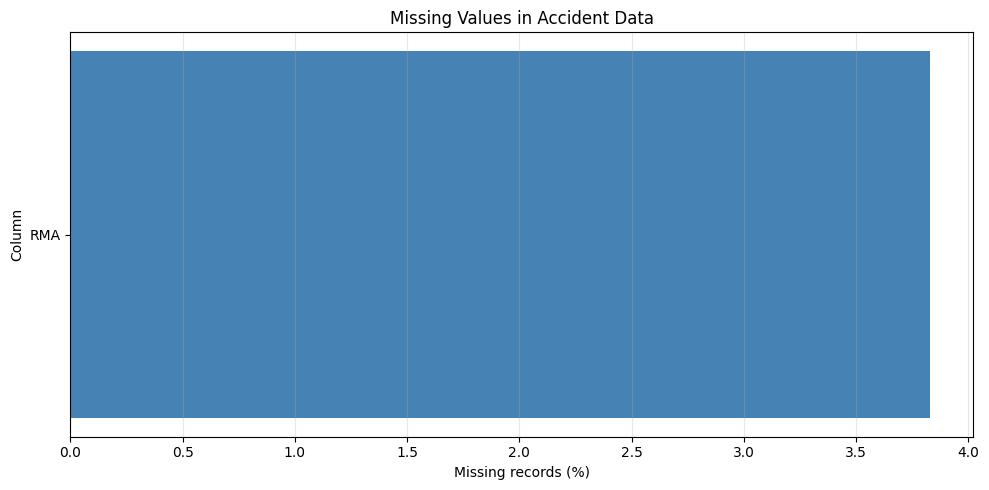

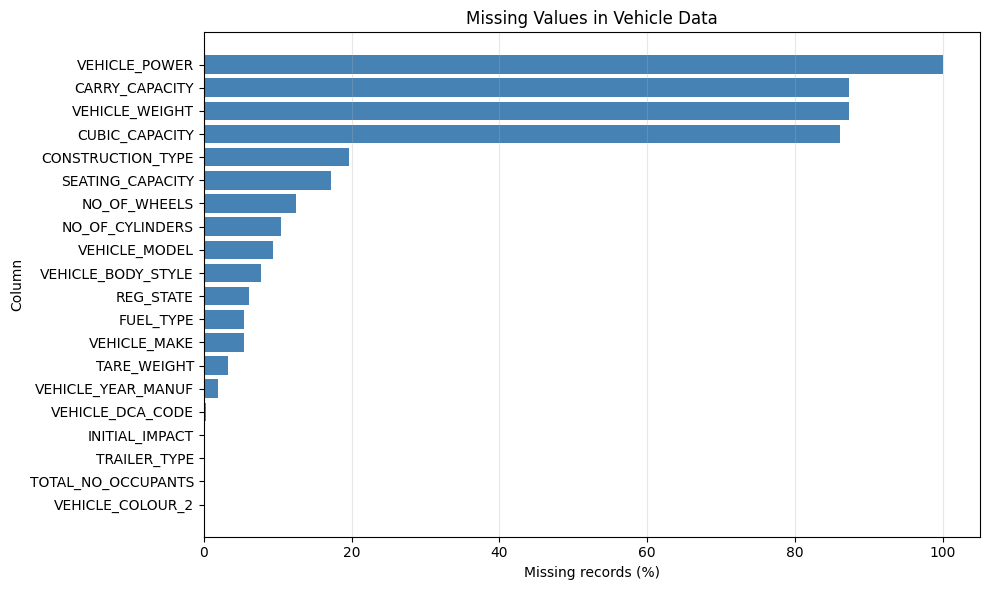

In [9]:
def plot_missing_values(completeness, dataset_name):
    chart_data = completeness[
        completeness["Missing percentage"] > 0
    ].sort_values("Missing percentage")

    if chart_data.empty:
        print(f"No missing values found in {dataset_name}")
        return

    plt.figure(
        figsize=(10, max(5, len(chart_data) * 0.3))
    )

    plt.barh(
        chart_data["Column"],
        chart_data["Missing percentage"],
        color="steelblue"
    )

    plt.title(f"Missing Values in {dataset_name}")
    plt.xlabel("Missing records (%)")
    plt.ylabel("Column")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_missing_values(
    accident_completeness,
    "Accident Data"
)

plot_missing_values(
    vehicle_completeness,
    "Vehicle Data"
)